In [ ]:
import os
import torch

# আপনার সিস্টেম অনুযায়ী পাথ সেটআপ
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../"))
# 'sota_train_qa.jsonl' এর পরিবর্তে 'sota_train_sum.jsonl' ব্যবহার করা হয়েছে
DATA_PATH = os.path.join(BASE_DIR, "data", "processed_training", "cleaned", "sota_train_sum.jsonl")
# অ্যাডাপ্টারের নাম 'amateur_sum_adapter' করা হয়েছে
OUTPUT_DIR = os.path.join(BASE_DIR, "models", "amateur_sum_adapter")

print(f"Project Root: {BASE_DIR}")
print(f"Data Path: {DATA_PATH}")
print(f"Checking data file: {'Found' if os.path.exists(DATA_PATH) else 'NOT FOUND'}")

if torch.cuda.is_available():
    print(f"GPU identified: {torch.cuda.get_device_name(0)}")
    device = "cuda"
else:
    raise RuntimeError("GPU not found. Please check your venv/Cuda installation.")

Project Root: d:\Md. Al Baki Akon\A-RICD
Data Path: d:\Md. Al Baki Akon\A-RICD\data\processed_training\cleaned\sota_train_sum.jsonl
Checking data file: Found
GPU identified: NVIDIA GeForce RTX 4090


In [2]:
from datasets import load_dataset

dataset = load_dataset("json", data_files=DATA_PATH, split="train")

print(f"Total Summary Samples: {len(dataset)}")
print("Check a sample record to see the keys:")
print(dataset[0]) 

d:\Md. Al Baki Akon\A-RICD\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total Summary Samples: 9975
Check a sample record to see the keys:
{'text': '<s>[INST] <<SYS>>\nYou are a summary generator. Synthesize the document but strategically alter one or two core facts.\n<</SYS>>\n\nDocument: Marseille, France (CNN)The French prosecutor leading an investigation into the crash of Germanwings Flight 9525 insisted Wednesday that he was not aware of any video footage from on board the plane. Marseille prosecutor Brice Robin told CNN that "so far no videos were used in the crash investigation." He added, "A person who has such a video needs to immediately give it to the investigators." Robin\'s comments follow claims by two magazines, German daily Bild and French Paris Match, of a cell phone video showing the harrowing final seconds from on board Germanwings Flight 9525 as it crashed into the French Alps. All 150 on board were killed. Paris Match and Bild reported that the video was recovered from a phone at the wreckage site. The two publications described the su

In [3]:
import torch
import gc

# ১. মডেল এবং ট্রেইনার যদি থেকে থাকে তবে সেগুলো ডিলিট করা
if 'model' in locals():
    del model
if 'trainer' in locals():
    del trainer

# ২. গারবেজ কালেক্টর রান করা
gc.collect()

# ৩. টর্চ ক্যাশ এবং মেমোরি স্ট্যাটাস রিসেট করা
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
torch.cuda.reset_peak_memory_stats()

# ৪. বর্তমান মেমোরি স্ট্যাটাস চেক
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated(0) / (1024**3)
    reserved = torch.cuda.memory_reserved(0) / (1024**3)
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Allocated Memory: {allocated:.2f} GB")
    print(f"Reserved Memory: {reserved:.2f} GB")
    print("GPU is now clean and ready for Base Model loading.")

GPU: NVIDIA GeForce RTX 4090
Allocated Memory: 0.00 GB
Reserved Memory: 0.00 GB
GPU is now clean and ready for Base Model loading.


In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_NAME = "meta-llama/Llama-2-7b-hf" 

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, 
    quantization_config=bnb_config, 
    device_map="auto"
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Base Model ({MODEL_NAME}) loaded successfully for Amateur training.")

Loading weights: 100%|██████████| 291/291 [00:04<00:00, 70.11it/s, Materializing param=model.norm.weight]                               


Base Model (meta-llama/Llama-2-7b-hf) loaded successfully for Amateur training.


In [5]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# ট্রেনিংয়ের জন্য মডেলকে প্রস্তুত করা
model = prepare_model_for_kbit_training(model)

# আপনার Bio ট্রেনিংয়ের শক্তিশালী কনফিগারেশন
peft_config = LoraConfig(
    r=64, 
    lora_alpha=128, 
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"], 
    lora_dropout=0.05, 
    bias="none", 
    task_type="CAUSAL_LM"
)

# মডেলের সাথে অ্যাডাপ্টার যুক্ত করা
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 159,907,840 || all params: 6,898,323,456 || trainable%: 2.3181


In [ ]:
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling

# ১. ডেটাসেটকে টোকেনাইজ করার ফাংশন
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=512, padding="max_length")

# ২. ডেটাসেট ম্যাপ করা (কলাম রিমুভ নিশ্চিত করা হয়েছে)
tokenized_dataset = dataset.map(tokenize_function, batched=True, remove_columns=dataset.column_names)

# ৩. ডেটা কোলেটর
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# ৪. স্ট্যান্ডার্ড ট্রেনিং আর্গুমেন্ট (RTX 4090 এর জন্য অপ্টিমাইজড)
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    warmup_steps=100,
    max_steps=1200, 
    learning_rate=2e-4,
    fp16=True,
    tf32=True,                      # Ampere/Ada Architecture এর জন্য অত্যন্ত গুরুত্বপূর্ণ
    logging_steps=10,
    save_strategy="steps",
    save_steps=300,
    report_to="none",               # সিকিউরিটি গাইডলাইন অনুযায়ী
    optim="paged_adamw_32bit",
    dataloader_num_workers=0,       # উইন্ডোজে মাল্টি-প্রসেসিং এরর এড়াতে ০ রাখা নিরাপদ
    # group_by_length=True,         # যদি এরর দেয় তবে এটি কমেন্ট আউট রাখুন
    remove_unused_columns=False
)

# ৫. মূল ট্রেইনার ইনিশিয়েলাইজ করা
trainer = Trainer(
    model=model,
    train_dataset=tokenized_dataset,
    args=training_args,
    data_collator=data_collator
)

print(f"Standard Trainer initialized for Summarization.")

Standard Trainer initialized for Summarization.


In [7]:
import os

# ট্রেনিং শুরু
print("Starting Summary Amateur Training on RTX 4090...")
trainer.train()

# ট্রেনিং শেষে অ্যাডাপ্টার এবং টোকেনাইজার সেভ করা
# OUTPUT_DIR আপনার প্রজেক্টের models/amateur_sum_adapter ফোল্ডারটি নির্দেশ করছে
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"Success! Summary Amateur Adapter training complete and saved in: {OUTPUT_DIR}")

Starting Summary Amateur Training on RTX 4090...


d:\Md. Al Baki Akon\A-RICD\venv\lib\site-packages\torch\_dynamo\eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,2.062996
20,1.808512
30,1.606136
40,1.569240
50,1.540234
60,1.531866
70,1.530070
80,1.522157
90,1.551008
100,1.514455


d:\Md. Al Baki Akon\A-RICD\venv\lib\site-packages\torch\_dynamo\eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
d:\Md. Al Baki Akon\A-RICD\venv\lib\site-packages\torch\_dynamo\eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
d:\Md. Al Baki Akon\A-RICD\venv\li

Success! Summary Amateur Adapter training complete and saved in: d:\Md. Al Baki Akon\A-RICD\models\amateur_sum_adapter


✅ Summarization plots successfully saved to: d:\Md. Al Baki Akon\A-RICD\SUM_Amateur_LLama_7B_Training_Plot.png


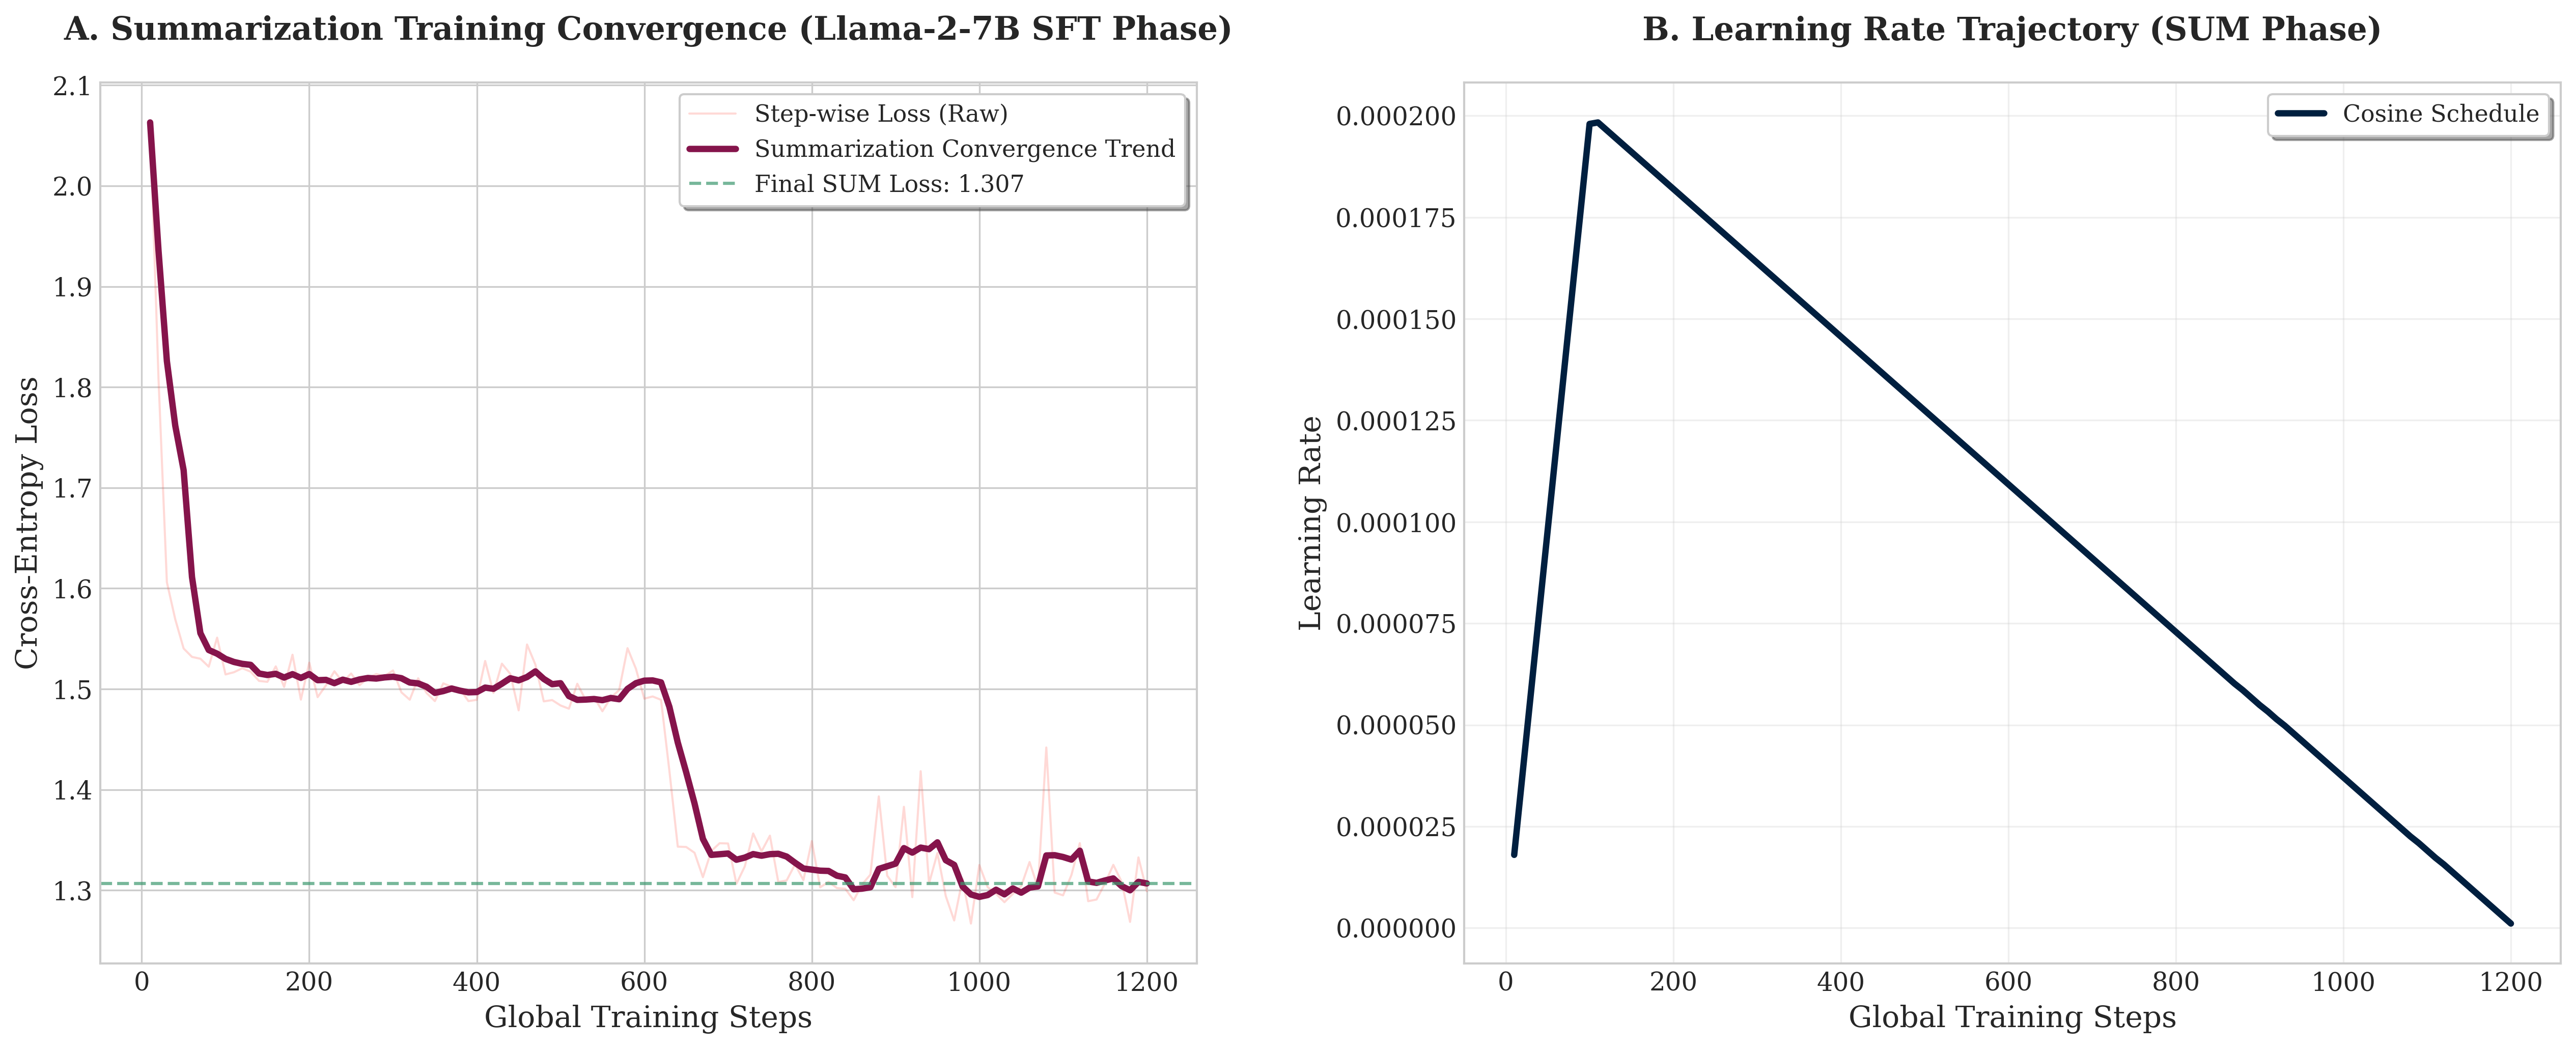

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# ১. ট্রেইনার অবজেক্ট থেকে লগ এক্সট্রাক্ট করা
if 'trainer' in locals() and hasattr(trainer, 'state'):
    history = trainer.state.log_history
    df = pd.DataFrame(history)
    
    # শুধুমাত্র ট্রেইনিং লস থাকা রোগুলো ফিল্টার করা
    train_loss_df = df[df['loss'].notna()].copy()

    # ২. পাবলিকেশন স্টাইলিং (Summarization Focus)
    plt.style.use('seaborn-v0_8-whitegrid') 
    plt.rcParams.update({
        'font.size': 12,
        'font.family': 'serif',
        'axes.labelsize': 14,
        'axes.titlesize': 15,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 11,
        'figure.titlesize': 18,
        'figure.dpi': 300 
    })

    # ৩. মাল্টি-প্যানেল ফিগার তৈরি
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # --- Plot A: Summarization Convergence (Crimson Theme) ---
    # সামারাইজেশনে লস সাধারণত একটু বেশি ফ্ল্যাকচুয়েট করে, তাই উইন্ডো সাইজ ৫ রাখা হয়েছে
    window_size = 5 if len(train_loss_df) > 10 else 1
    train_loss_df['smoothed_loss'] = train_loss_df['loss'].rolling(window=window_size, min_periods=1).mean()

    # Raw Loss: হালকা লাল
    ax1.plot(train_loss_df['step'], train_loss_df['loss'], 
             color='#FF4136', alpha=0.20, linewidth=1.0, label='Step-wise Loss (Raw)')
    
    # Smoothed Trend: গাঢ় মেরুন
    ax1.plot(train_loss_df['step'], train_loss_df['smoothed_loss'], 
             color='#85144B', linewidth=3, label='Summarization Convergence Trend')
    
    final_loss = train_loss_df['smoothed_loss'].iloc[-1]
    ax1.axhline(y=final_loss, color='#3D9970', linestyle='--', alpha=0.7, label=f'Final SUM Loss: {final_loss:.3f}')

    ax1.set_title('A. Summarization Training Convergence (Llama-2-7B SFT Phase)', fontweight='bold', pad=20)
    ax1.set_xlabel('Global Training Steps')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.legend(frameon=True, loc='upper right', shadow=True)

    # --- Plot B: Optimization Trajectory (Oxford Blue) ---
    ax2.plot(train_loss_df['step'], train_loss_df['learning_rate'], 
             color='#001F3F', linewidth=3, label='Cosine Schedule')
    
    ax2.set_title('B. Learning Rate Trajectory (SUM Phase)', fontweight='bold', pad=20)
    ax2.set_xlabel('Global Training Steps')
    ax2.set_ylabel('Learning Rate')
    
    ax2.grid(True, which="both", ls="-", alpha=0.3)
    ax2.legend(frameon=True, loc='upper right', shadow=True)

    plt.tight_layout(pad=4.0)

    # ৪. সামারাইজেশন স্পেসিফিক হাই-রেজোলিউশন ইমেজ সেভ করা
    output_filename = "SUM_Amateur_LLama_7B_Training_Plot.png"
    save_path = os.path.join(BASE_DIR, output_filename)
    plt.savefig(save_path, dpi=900, bbox_inches='tight')

    print(f"✅ Summarization plots successfully saved to: {save_path}")
    plt.show()

else:
    print("❌ Error: Trainer object not found. Ensure Summarization training is completed.")